# Configs and Imports

In [71]:
# === Cell 1 — Imports, config, robust helpers ===
import os, glob, math, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,4)
np.random.seed(42)

CORE_COLS = ["timestamp","RPM","SPEED","THROTTLE_POS","MAF","ENGINE_LOAD"]
KMH_TO_MS = 1000.0/3600.0

def ensure_dt(s): return pd.to_datetime(s, errors="coerce", utc=True)

def infer_base_interval_seconds(ts: pd.Series) -> float:
    if ts.size < 2: return 1.0
    d = ts.sort_values().diff().dropna().dt.total_seconds()
    d = d[d>0]
    if d.empty: return 1.0
    q05,q95 = d.quantile([0.05,0.95])
    core = d[(d>=q05)&(d<=q95)]
    rounded = (core/0.01).round()*0.01
    mode = rounded.mode()
    return float(mode.iloc[0] if not mode.empty else core.median())

def rows_for(seconds, dt): return max(3, int(round(seconds/max(dt,1e-3))))

def run_lengths(mask: np.ndarray):
    m = mask.astype(bool)
    idx = np.flatnonzero(np.diff(np.r_[False, m, False]))
    starts, ends = idx[::2], idx[1::2]
    return starts, (ends - starts)

def safe_num(df, cols):
    for c in cols:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def robust_scale_01(s):
    rs = RobustScaler().fit_transform(s.values.reshape(-1,1)).ravel()
    return np.clip(MinMaxScaler().fit_transform(rs.reshape(-1,1)).ravel(), 0, 1)

# Data

In [72]:
# === Cell 2 — Merge many CSVs, segment drives, clean + dynamics ===
CSV_PATTERN = "*.csv"
files = sorted(glob.glob(CSV_PATTERN))
if not files: raise FileNotFoundError("No CSV files matched. Set CSV_PATTERN.")

dfs = []
for fp in files:
    df = pd.read_csv(fp)
    keep = [c for c in CORE_COLS if c in df.columns]
    df = df[keep].copy()
    df["source_file"] = os.path.basename(fp)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df["timestamp"] = ensure_dt(df["timestamp"])
df = safe_num(df, [c for c in CORE_COLS if c!="timestamp"])
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# segment drives by gaps (>5 min) or file switch
gap_sec = 5*60
dt = df["timestamp"].diff().dt.total_seconds().fillna(0)
new_drive = (dt > gap_sec) | (df["source_file"].ne(df["source_file"].shift()))
df["drive_id"] = new_drive.cumsum()

# impute missing numeric
num_cols = [c for c in df.columns if c not in ["timestamp","source_file","drive_id"]]
df[num_cols] = KNNImputer(n_neighbors=3).fit_transform(df[num_cols])

# base cadence + dynamics
base_sec = infer_base_interval_seconds(df["timestamp"])
df["SPEED_ms"] = df["SPEED"]*KMH_TO_MS
df["ACCEL"] = df["SPEED_ms"].diff()/max(base_sec,1e-3)                 # m/s^2
df["JERK"]  = df["ACCEL"].diff()/max(base_sec,1e-3)                     # m/s^3

# rolling windows
W5, W10 = rows_for(5, base_sec), rows_for(10, base_sec)
for col in ["SPEED_ms","RPM","ENGINE_LOAD","THROTTLE_POS","MAF","ACCEL","JERK"]:
    if col not in df.columns: continue
    df[f"{col}_mean_w5"] = df[col].rolling(W5, min_periods=1).mean()
    df[f"{col}_std_w5"]  = df[col].rolling(W5, min_periods=1).std()
    df[f"{col}_mean_w10"] = df[col].rolling(W10, min_periods=1).mean()
    df[f"{col}_std_w10"]  = df[col].rolling(W10, min_periods=1).std()

# distance estimate (meters)
dt_s = df["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=0, upper=10*base_sec)
df["dist_m"] = (df["SPEED_ms"] * dt_s).fillna(0)
print(f"Files: {len(files)} | Drives: {df['drive_id'].nunique()} | Rows: {len(df):,}")
df.head(3)

Files: 10 | Drives: 10 | Rows: 2,378


,timestamp,RPM,SPEED,THROTTLE_POS,MAF,ENGINE_LOAD,source_file,drive_id,SPEED_ms,ACCEL,...,MAF_std_w10,ACCEL_mean_w5,ACCEL_std_w5,ACCEL_mean_w10,ACCEL_std_w10,JERK_mean_w5,JERK_std_w5,JERK_mean_w10,JERK_std_w10,dist_m
0,2025-09-28 13:28:43.286472+00:00,766.25,0.0,12.54902,4.55,2.352941,obd_data_log_20250928_132843.csv,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-09-28 13:28:44.710016+00:00,755.75,0.0,12.54902,4.49,2.352941,obd_data_log_20250928_132843.csv,1,0.0,0.0,...,0.042426,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,2025-09-28 13:28:46.085703+00:00,768.25,0.0,12.54902,4.54,2.352941,obd_data_log_20250928_132843.csv,1,0.0,0.0,...,0.032146,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0


# Fleeth threshold + Idle

ACCEL_thr=2.56 m/s^2  |  JERK_thr=7.89 m/s^3


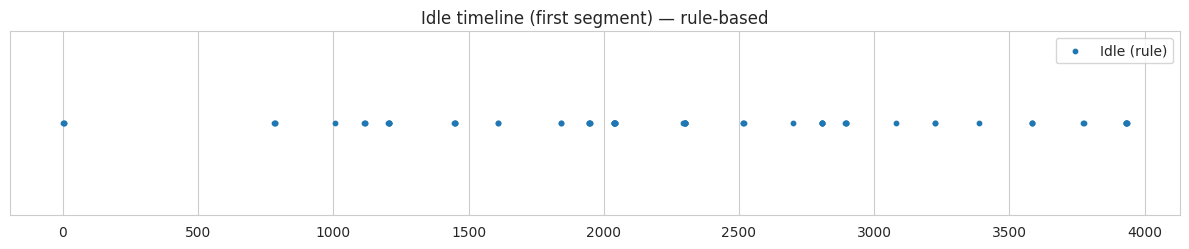

count    10.000000
mean      0.029653
std       0.014866
min       0.012195
25%       0.015959
50%       0.031526
75%       0.037927
max       0.059259
Name: idle_frac, dtype: float64


In [73]:
# === Cell 3 — Fleet thresholds + RULE Idle mask ===
# Prereqs: df has per-row dynamics; use Cell 2/3 from earlier (SPEED_ms, ACCEL, JERK, IDLE_RULE, dist_m, base_sec exist)

from sklearn.linear_model import LinearRegression
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# 1) Build per-drive aggregates (length-invariant)
def _run_lengths(mask: np.ndarray):
    m = mask.astype(bool)
    idx = np.flatnonzero(np.diff(np.r_[False, m, False]))
    return idx[::2], idx[1::2] - idx[::2]

base_sec = infer_base_interval_seconds(df["timestamp"])
thr_accel = max(0.6, df["ACCEL"].abs().quantile(0.85))
thr_jerk  = max(0.6, df["JERK"].abs().quantile(0.90))
sharp_mask = (df["ACCEL"].abs()>thr_accel) | (df["JERK"].abs()>thr_jerk)

print(f"ACCEL_thr={thr_accel:.2f} m/s^2  |  JERK_thr={thr_jerk:.2f} m/s^3")

# Idle: near-zero motion + minimal throttle/load/MAF (no ML)
speed_low   = (df["SPEED_ms"].abs() <= 0.6)                     # ~<=2.2 km/h
thr_low     = (df["THROTTLE_POS"] <= df["THROTTLE_POS"].quantile(0.10)) if "THROTTLE_POS" in df else True
load_low    = (df["ENGINE_LOAD"]  <= df["ENGINE_LOAD"].quantile(0.15))  if "ENGINE_LOAD"  in df else True
maf_low     = (df["MAF"]          <= df["MAF"].quantile(0.10))          if "MAF"          in df else True
accel_low   = (df["ACCEL"].abs()  <= df["ACCEL"].abs().quantile(0.20))
idle_rule   = (speed_low & thr_low & load_low & maf_low & accel_low).astype(bool)

# debounce small flicker
from scipy.signal import medfilt
df["IDLE_RULE"] = medfilt(idle_rule.astype(int), kernel_size=5).astype(bool)

# quick sanity plot
plt.figure(figsize=(12,2.6))
N = min(2500, len(df))
t0 = (df["timestamp"].iloc[:N]-df["timestamp"].iloc[0]).dt.total_seconds()
plt.scatter(t0[df["IDLE_RULE"].iloc[:N]], np.zeros(df["IDLE_RULE"].iloc[:N].sum())+0.5, s=10, label="Idle (rule)")
plt.yticks([]); plt.title("Idle timeline (first segment) — rule-based"); plt.legend(); plt.tight_layout(); plt.show()

idle_frac = df.groupby("drive_id")["IDLE_RULE"].mean().rename("idle_frac")
idle_dur_s = []
for gid, g in df.groupby("drive_id"):
    starts, lens = run_lengths(g["IDLE_RULE"].values)
    idle_dur_s.append(pd.Series({"drive_id":gid,
                                 "idle_episodes":len(lens),
                                 "idle_median_dur_s": float(np.median(lens)*base_sec if len(lens) else 0.0)}))
idle_dur_s = pd.DataFrame(idle_dur_s).set_index("drive_id")
print(idle_frac.describe())

# Algorithmic efficiency

Learned weights: {'p_freq': np.float64(0.059), 'p_dur': np.float64(0.443), 'p_mag': np.float64(0.0), 'p_idle': np.float64(0.0), 'p_cv': np.float64(0.0)}
Efficiency range: 65.81 → 84.05


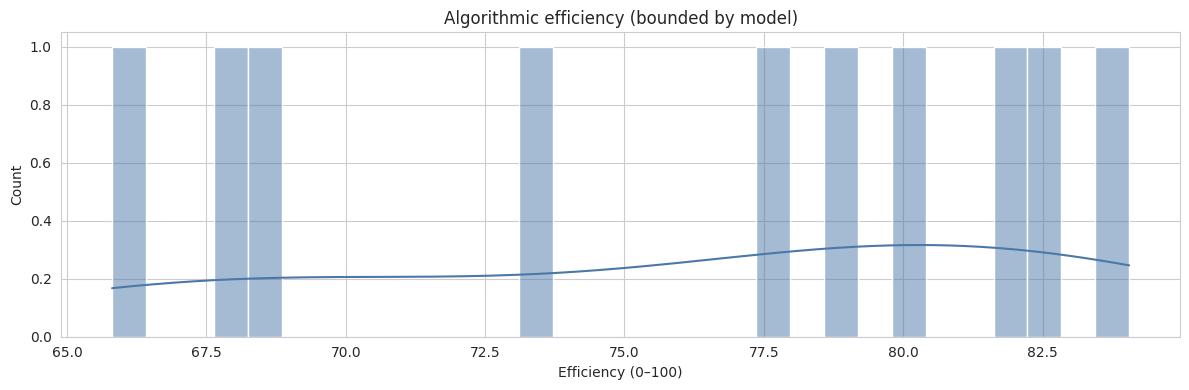

,duration_min,distance_km,freq_pm,dur_frac,sharp_mag,idle_frac,idle_med_s,idle_epm,speed_cv,proxy,ineff_model,efficiency_algo,p_freq,p_dur,p_mag,p_idle,p_cv
drive_id,,,,,,,,,,,,,,,,,
1,2.458542,2.416524,17.083292,0.308448,0.518452,0.015873,1.95,0.406745,0.241577,0.272751,0.341914,65.808558,0.884028,0.826427,0.531375,0.585077,0.362415
2,3.134787,2.416456,6.061018,0.141690,0.721930,0.012195,1.95,0.319001,0.185610,0.094512,0.209306,79.069409,0.311512,0.488368,0.844244,0.577777,0.105226
3,3.337046,2.417647,7.191989,0.103884,0.485764,0.034615,1.95,0.898999,0.262189,0.069038,0.180398,81.960155,0.376771,0.398705,0.468625,0.630207,0.503834
4,2.704575,2.415658,10.722572,0.196272,0.637356,0.028436,1.95,0.739488,0.261099,0.159953,0.265873,73.412709,0.599013,0.617624,0.738829,0.614649,0.496166
5,3.364225,2.419536,8.917358,0.151347,0.455278,0.059259,3.25,0.891736,0.310562,0.101667,0.225358,77.464172,0.484707,0.511632,0.410943,0.705416,0.798527


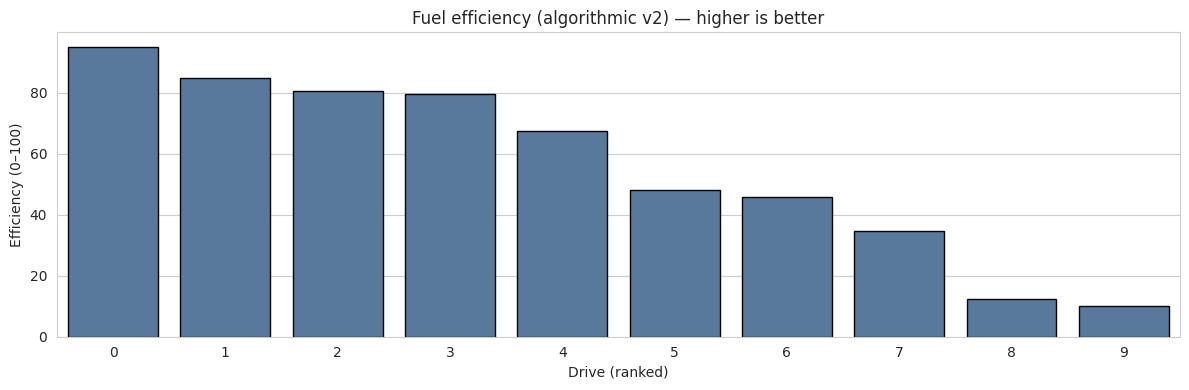

In [82]:

drv = []
for gid, g in df.groupby("drive_id", sort=True):
    if len(g) < 5:
        continue
    dt_s = g["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=0, upper=10*base_sec)
    T = float(dt_s.sum()); mins = max(1e-6, T/60)
    # sharp episodes
    s = sharp_mask.loc[g.index].values
    st, ln = _run_lengths(s)
    # frequency/duration
    freq_pm = len(ln)/mins
    dur_frac = (ln.sum()*base_sec)/max(1e-6, T)
    # sharpness magnitude (episode peak-over-threshold, capped; sharpness not over-penalized)
    peaks = []
    for a,b in zip(st, ln):
        seg = g.iloc[a:a+b]
        pa, pj = float(seg["ACCEL"].abs().max()), float(seg["JERK"].abs().max())
        over_a = max(0.0, (pa-thr_accel)/thr_accel)
        over_j = max(0.0, (pj-thr_jerk)/thr_jerk)
        peaks.append(min(1.5, 0.7*over_a + 0.3*over_j))
    sharp_mag = float(np.mean(peaks)) if peaks else 0.0
    # idle signals
    idle_frac = float(g["IDLE_RULE"].mean())
    sti, lni = _run_lengths(g["IDLE_RULE"].values)
    idle_med_s = float(np.median(lni)*base_sec if len(lni) else 0.0)
    idle_epm = len(lni)/mins
    # speed steadiness
    sp_cv = float((g["SPEED_ms_std_w10"]/(g["SPEED_ms_mean_w10"]+1e-6)).mean())

    # fuel-demand proxies (targets for weight learning)
    frac_maf90  = g["MAF"].ge(df["MAF"].quantile(0.90)).mean() if "MAF" in g else 0.0
    frac_load85 = g["ENGINE_LOAD"].ge(df["ENGINE_LOAD"].quantile(0.85)).mean() if "ENGINE_LOAD" in g else 0.0
    frac_thr85  = g["THROTTLE_POS"].ge(df["THROTTLE_POS"].quantile(0.85)).mean() if "THROTTLE_POS" in g else 0.0

    drv.append({
        "drive_id":gid,"duration_min":mins,"distance_km":g["dist_m"].sum()/1000.0,
        "freq_pm":freq_pm,"dur_frac":dur_frac,"sharp_mag":sharp_mag,
        "idle_frac":idle_frac,"idle_med_s":idle_med_s,"idle_epm":idle_epm,"speed_cv":sp_cv,
        # proxy for learning weights (higher proxy ⇒ more fuel demand)
        "proxy": 0.40*frac_maf90 + 0.30*frac_load85 + 0.15*frac_thr85 + 0.15*idle_frac
    })
dfeat = pd.DataFrame(drv).set_index("drive_id")

# 2) Smooth, bounded penalties per component via sigmoids (data-driven centers/slopes)
def sigmoid(x): return 1/(1+np.exp(-x))
def penalty(series):
    q25, q50, q75 = np.quantile(series, [0.25,0.50,0.75])
    s = (q75 - q25)/1.349 if (q75>q25) else max(1e-6, series.std())
    return sigmoid((series - q50)/max(1e-6, s))

P = pd.DataFrame({
    "p_freq": penalty(dfeat["freq_pm"]),
    "p_dur":  penalty(dfeat["dur_frac"]),
    "p_mag":  penalty(dfeat["sharp_mag"]),
    "p_idle": sigmoid( 0.7*(penalty(dfeat["idle_frac"])) + 0.3*(penalty(dfeat["idle_med_s"])) ),
    "p_cv":   penalty(dfeat["speed_cv"])
}, index=dfeat.index)

# 3) Learn weights (non-negative) against proxy by fitting the exponential combiner:
#    ineff_hat = 1 - exp(-P @ w)  ⇒  -log(1 - proxy_clip) ≈ P @ w
proxy = dfeat["proxy"].clip(0, 1-1e-6)                 # keep in (0,1)
target_lin = -np.log(1 - proxy)                           # invert combiner
lr = LinearRegression(positive=True).fit(P.values, target_lin.values)
w = lr.coef_
dfeat["ineff_model"] = 1 - np.exp(-P.values @ w)       # in (0,1)

# 4) Final efficiency (bounded; no batch min-max)
dfeat["efficiency_algo"] = 100*(1 - dfeat["ineff_model"])

# 5) Diagnostics
print("Learned weights:", dict(zip(P.columns, np.round(w,3))))
print("Efficiency range:", round(dfeat["efficiency_algo"].min(),2), "→", round(dfeat["efficiency_algo"].max(),2))

plt.figure(figsize=(12,4))
sns.histplot(dfeat["efficiency_algo"], bins=30, kde=True, color="#4C78A8")
plt.title("Algorithmic efficiency (bounded by model)"); plt.xlabel("Efficiency (0–100)")
plt.tight_layout(); plt.show()

# Keep a merged per-drive table for ML training in Cell B
per_drive = dfeat.join(P)
display(per_drive.head(5))

# Plot
plt.figure(figsize=(12,4))
sns.barplot(x=np.arange(len(ranked)), y=ranked["efficiency_algo_v2"], color="#4C78A8", edgecolor="black")
plt.title("Fuel efficiency (algorithmic v2) — higher is better"); plt.xlabel("Drive (ranked)"); plt.ylabel("Efficiency (0–100)")
plt.tight_layout(); plt.show()

# Shading + Sharp episode

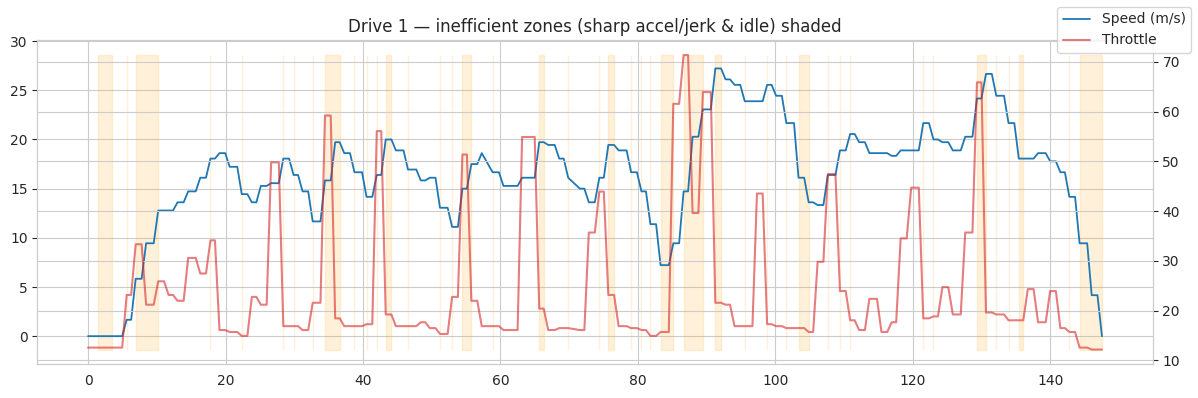

,peak_over_thr,dur_s
count,42.000000,42.000000
mean,1.734126,1.083333
std,0.648178,0.781935
min,1.000000,0.650000
25%,1.166666,0.650000
50%,1.583333,0.650000
75%,2.166666,1.300000
max,3.333332,3.250000


In [83]:
# === Cell 5 — Inspect a drive: timeline shading + sharp episode stats ===
if len(ranked)==0: raise RuntimeError("No drives scored.")
drive_to_show = int(ranked.tail(1).index[0])  # worst case by v2 score
g = df[df["drive_id"]==drive_to_show].copy()
t = (g["timestamp"]-g["timestamp"].iloc[0]).dt.total_seconds()

# recompute sharp mask for this drive
g_sharp = (g["ACCEL"].abs()>thr_accel) | (g["JERK"].abs()>thr_jerk)
ineff_zone = g_sharp | g["IDLE_RULE"]

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(t, g["SPEED_ms"], label="Speed (m/s)", linewidth=1.3)
ax2 = ax1.twinx()
ax2.plot(t, g["THROTTLE_POS"], color="#D62728", alpha=0.6, label="Throttle")
ax1.fill_between(t, ax1.get_ylim()[0], ax1.get_ylim()[1], where=ineff_zone, color="orange", alpha=0.15, step="pre")
ax1.set_title(f"Drive {drive_to_show} — inefficient zones (sharp accel/jerk & idle) shaded")
fig.legend(loc="upper right"); plt.tight_layout(); plt.show()

# sharp episode table
starts, lens = run_lengths(g_sharp.values)
peaks, kinds = [], []
for st, ln in zip(starts, lens):
    seg = g.iloc[st:st+ln]
    pa, pj = float(seg["ACCEL"].abs().max()), float(seg["JERK"].abs().max())
    peaks.append(max(pa/ (thr_accel+1e-6), pj/(thr_jerk+1e-6)))
    kinds.append("accel" if pa>=pj else "jerk")
ep_df = pd.DataFrame({"kind":kinds, "peak_over_thr":peaks, "dur_s": lens*infer_base_interval_seconds(g["timestamp"])})
display(ep_df.describe())


# ML - GradientBoostingRegressor

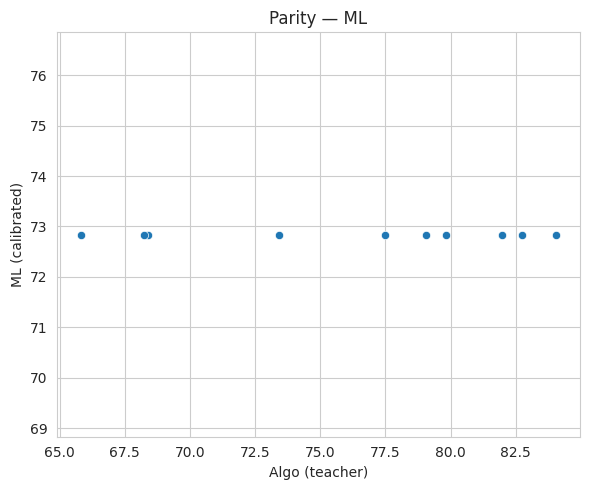

Calibrated MAE: 6.48


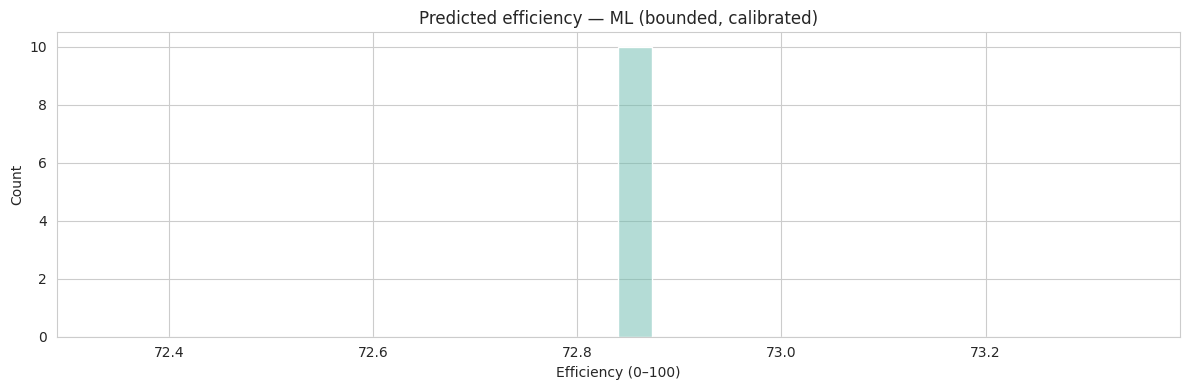

In [89]:
# === Cell 6 - monotonic GBM + isotonic calibration (learned once) ===
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# 1) Build ML features (length-invariant) & target from algorithm
def agg_for_ml(g):
    dt = g["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=0, upper=10*base_sec)
    T = float(dt.sum()); mins = max(1e-6, T/60)
    def q(s,p): return float(np.nanquantile(s, p))
    thr_a, thr_j = thr_accel, thr_jerk
    sharp = ((g["ACCEL"].abs()>thr_a) | (g["JERK"].abs()>thr_j)).values
    fr = len(np.flatnonzero(np.diff(np.r_[False, sharp, False])))//2 / mins

    feats = {
        "duration_min": mins,
        "distance_km": g["dist_m"].sum()/1000.0,
        "speed_mean": float(g["SPEED_ms"].mean()),
        "speed_q90": q(g["SPEED_ms"],0.90),
        # "speed_cv": float((g["SPEED_ms_std_w10"]/(g["SPEED_ms_mean_w10"]+1e-6)).mean()),
        "accel_q90": q(g["ACCEL"].abs(),0.90),
        "jerk_q90": q(g["JERK"].abs(),0.90),
        "sharp_freq_pm": fr,
        "idle_frac": float(g["IDLE_RULE"].mean()),
        "idle_epm": len(np.flatnonzero(np.diff(np.r_[False, g["IDLE_RULE"].values, False])))//2 / mins,
        "rpm_q90": q(g["RPM"],0.90) if "RPM" in g else 0.0,
        "load_q85": q(g["ENGINE_LOAD"],0.85) if "ENGINE_LOAD" in g else 0.0,
        "thr_q85": q(g["THROTTLE_POS"],0.85) if "THROTTLE_POS" in g else 0.0,
        "maf_q90": q(g["MAF"],0.90) if "MAF" in g else 0.0,
    }
    return feats

rows, y = [], []
groups = []
for gid in per_drive.index:
    g = df[df["drive_id"]==gid]
    if len(g) < 5: continue
    rows.append(agg_for_ml(g))
    y.append(per_drive.loc[gid, "efficiency_algo"])
    groups.append(g["source_file"].iloc[0])

X = pd.DataFrame(rows)
y = np.array(y); groups = np.array(groups)

# Standardize non-length features; keep scalers for inference
num_cols = [c for c in X.columns if c not in ["duration_min","distance_km"]]
sc_ml = StandardScaler().fit(X[num_cols])
X[num_cols] = sc_ml.transform(X[num_cols])

# 2) Monotonic constraints: features that should LOWER efficiency as they increase ⇒ -1, neutral ⇒ 0
mono_features = ["accel_q90","jerk_q90","sharp_freq_pm","idle_frac","idle_epm","rpm_q90","load_q85","thr_q85","maf_q90"]
mono = []
for col in X.columns:
    mono.append(-1 if col in mono_features else 0)

# 3) Grouped CV (by file) for calibration; fit on train, calibrate on val once
gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
train_idx, val_idx = next(gkf.split(X, y, groups=groups))  # first split is fine for a single calibrator

Xtr, Xval = X.iloc[train_idx], X.iloc[val_idx]
ytr, yval = y[train_idx], y[val_idx]
wtr = np.clip(Xtr["duration_min"].values, 0.5, None)  # weight longer drives a bit more

gbm = HistGradientBoostingRegressor(
    loss="squared_error",
    max_depth=6,
    learning_rate=0.07,
    max_bins=255,
    early_stopping=True,
    monotonic_cst=mono,
    random_state=42
)
gbm.fit(Xtr, ytr, sample_weight=wtr)

# 4) One-time isotonic calibration learned from validation predictions (not per batch)
raw_val = gbm.predict(Xval)
iso_cal = IsotonicRegression(out_of_bounds="clip").fit(raw_val, yval)

# 5) Fit final model on all data (same hyperparams), keep calibrator & scaler
w_all = np.clip(X["duration_min"].values, 0.5, None)
gbm.fit(X, y, sample_weight=w_all)

# Diagnostics: train-val parity & distribution
raw_all = gbm.predict(X)
pred_all = iso_cal.predict(raw_all)
plt.figure(figsize=(6,5))
sns.scatterplot(x=y, y=pred_all, s=35)
plt.xlabel("Algo (teacher)"); plt.ylabel("ML (calibrated)")
plt.title("Parity — ML"); plt.grid(True); plt.tight_layout(); plt.show()
print("Calibrated MAE:", np.mean(np.abs(y - pred_all)).round(2))

plt.figure(figsize=(12,4))
sns.histplot(pred_all, bins=30, kde=True, color="#6BBBAE")
plt.title("Predicted efficiency — ML (bounded, calibrated)"); plt.xlabel("Efficiency (0–100)")
plt.tight_layout(); plt.show()

# 6) Inference function (length-invariant; reuses sc_ml, gbm, iso_cal)
def predict_efficiency_ml(df_new: pd.DataFrame) -> float:
    d = df_new.copy()
    d["timestamp"] = ensure_dt(d["timestamp"])
    d = safe_num(d, [c for c in CORE_COLS if c!="timestamp"]).dropna(subset=["timestamp"]).sort_values("timestamp")
    if len(d)<5: return float("nan")
    base = infer_base_interval_seconds(d["timestamp"])
    d["SPEED_ms"] = d["SPEED"]*KMH_TO_MS
    d["ACCEL"] = d["SPEED_ms"].diff()/max(base,1e-3)
    d["JERK"]  = d["ACCEL"].diff()/max(base,1e-3)
    # rule idle (same as earlier)
    speed_low = (d["SPEED_ms"].abs() <= 0.6)
    thr_low   = (d["THROTTLE_POS"] <= df["THROTTLE_POS"].quantile(0.10)) if "THROTTLE_POS" in df else True
    load_low  = (d["ENGINE_LOAD"]  <= df["ENGINE_LOAD"].quantile(0.15))  if "ENGINE_LOAD" in df else True
    maf_low   = (d["MAF"]          <= df["MAF"].quantile(0.10))          if "MAF" in df else True
    accel_low = (d["ACCEL"].abs()  <= df["ACCEL"].abs().quantile(0.20))
    from scipy.signal import medfilt as _med
    d["IDLE_RULE"] = _med((speed_low & thr_low & load_low & maf_low & accel_low).astype(int), 5).astype(bool)

    # Minimal windows for features used by agg_for_ml()
    W10 = rows_for(10, base)
    for col in ["SPEED_ms"]:
        d[f"{col}_mean_w10"] = d[col].rolling(W10,1).mean()
        d[f"{col}_std_w10"]  = d[col].rolling(W10,1).std()
    d["dist_m"] = d["SPEED_ms"] * d["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=0, upper=10*base)

    feats = agg_for_ml(d)
    x = pd.DataFrame([feats], columns=X.columns)
    x[num_cols] = sc_ml.transform(x[num_cols])  # reuse training scaler
    y_raw = gbm.predict(x)
    return float(np.clip(iso_cal.predict(y_raw)[0], 0, 100))


# Chunking test

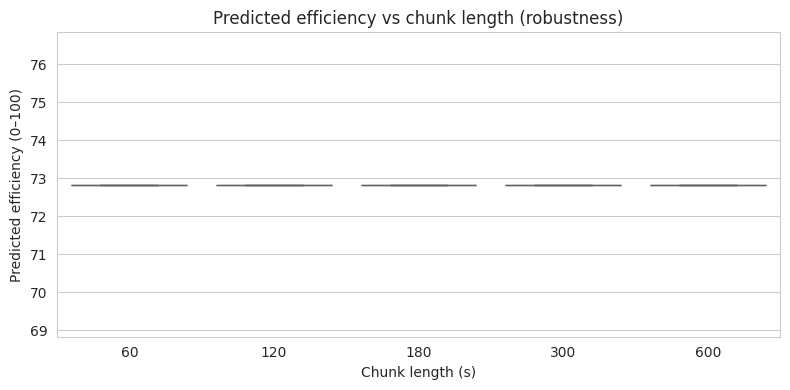

Std dev of predictions by chunk length:
 chunk_sec
60     0.0
120    0.0
180    0.0
300    0.0
600    0.0
Name: pred_eff, dtype: float64


In [95]:
# === Cell 7 — Robustness to trip length: random chunking test ===
rng = np.random.default_rng(42)
rows = []
for gid in ranked.index[: min(50, len(ranked))]:  # test on up to 50 drives
    g = df[df["drive_id"]==gid].copy()
    if len(g) < 120: continue
    n = len(g)
    for L in [60,120,180,300,600]:  # chunk lengths in seconds
        step = max(1, int(round(L/max(base_sec,1e-3))))
        for _ in range(4):
            start = rng.integers(0, max(1, n-step))
            chunk = g.iloc[start:start+step].copy()
            try:
                eff = predict_efficiency_ml(chunk[CORE_COLS])
            except KeyError as e:
                print(f"⚠️ Missing {e} in gid={gid}, L={L}, skipping")
                eff = np.nan
            rows.append({"drive_id":gid, "chunk_sec":L, "pred_eff":eff})

rob = pd.DataFrame(rows).dropna()
plt.figure(figsize=(8,4))
sns.boxplot(x="chunk_sec", y="pred_eff", data=rob, color="#9CCB86")
plt.title("Predicted efficiency vs chunk length (robustness)")
plt.xlabel("Chunk length (s)"); plt.ylabel("Predicted efficiency (0–100)")
plt.tight_layout(); plt.show()

sd_by_len = rob.groupby("chunk_sec")["pred_eff"].std()
print("Std dev of predictions by chunk length:\n", sd_by_len.round(2))


# Dashboards

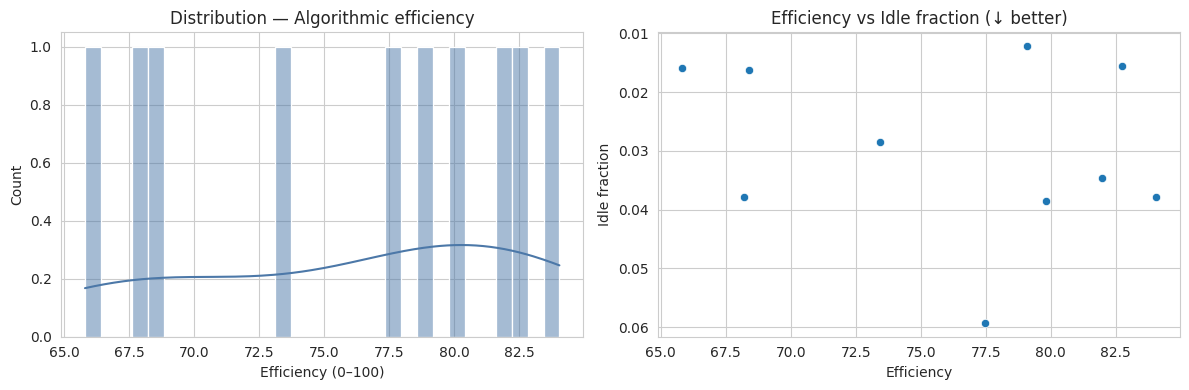

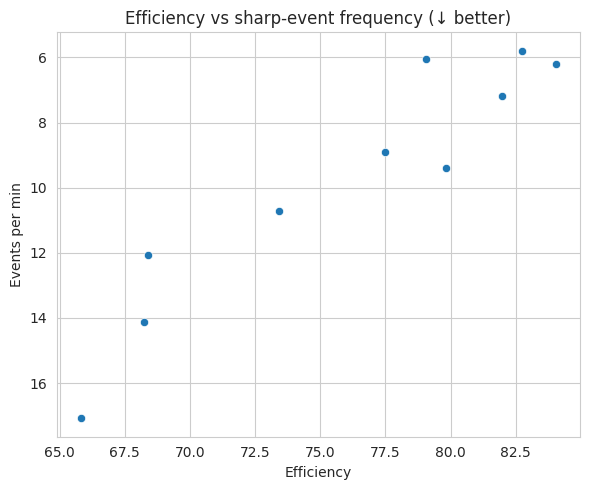

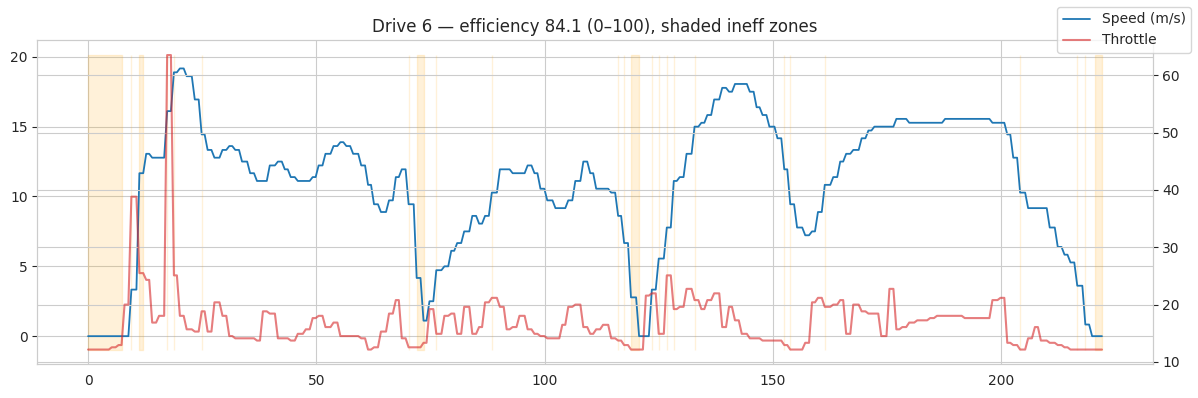

,peak_over_thr,dur_s
count,23.000000,23.000000
mean,1.724637,0.791304
std,0.874164,0.389829
min,1.000000,0.650000
25%,1.250000,0.650000
50%,1.499999,0.650000
75%,1.999999,0.650000
max,4.999998,1.950000


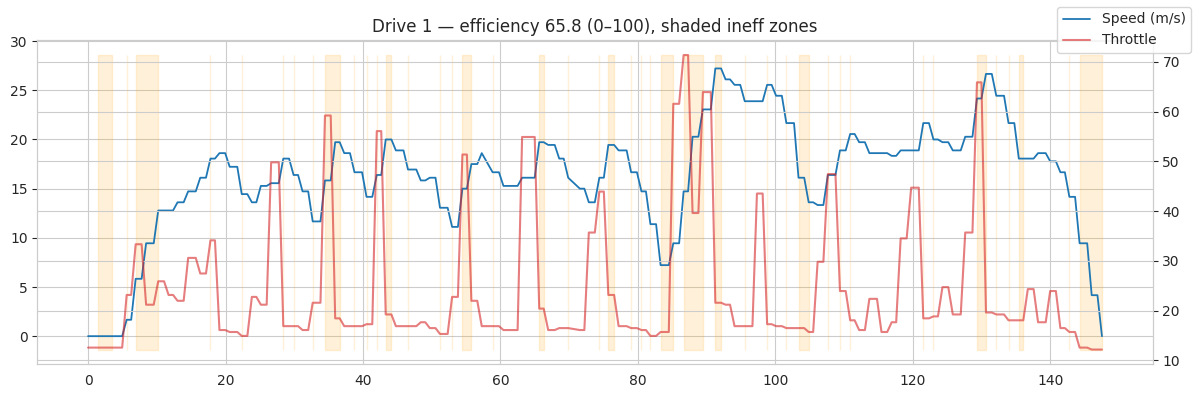

,peak_over_thr,dur_s
count,42.000000,42.000000
mean,1.734126,1.083333
std,0.648178,0.781935
min,1.000000,0.650000
25%,1.166666,0.650000
50%,1.583333,0.650000
75%,2.166666,1.300000
max,3.333332,3.250000


In [96]:
# === Cell 8.1 — Sanity dashboards ===
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); sns.histplot(dfeat["efficiency_algo"], bins=30, kde=True, color="#4C78A8")
plt.title("Distribution — Algorithmic efficiency"); plt.xlabel("Efficiency (0–100)")
plt.subplot(1,2,2);
sns.scatterplot(x=dfeat["efficiency_algo"], y=dfeat["idle_frac"], s=35)
plt.gca().invert_yaxis()
plt.title("Efficiency vs Idle fraction (↓ better)"); plt.xlabel("Efficiency"); plt.ylabel("Idle fraction")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=dfeat["efficiency_algo"], y=dfeat["freq_pm"], s=35)
plt.gca().invert_yaxis()
plt.title("Efficiency vs sharp-event frequency (↓ better)"); plt.xlabel("Efficiency"); plt.ylabel("Events per min")
plt.tight_layout(); plt.show()


# === Cell 8.2 — Per-drive timeline diagnostics & scoring ===

def plot_drive_timeline(drive_id, df, thr_accel, thr_jerk):
    """Plot one drive with shaded inefficient zones + efficiency scoring."""
    g = df[df["drive_id"]==drive_id].copy()
    if g.empty:
        return

    # time relative to start
    t = (g["timestamp"]-g["timestamp"].iloc[0]).dt.total_seconds()

    # inefficiency zones = sharp accel/jerk + idle
    g_sharp = (g["ACCEL"].abs()>thr_accel) | (g["JERK"].abs()>thr_jerk)
    ineff_zone = g_sharp | g["IDLE_RULE"]

    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(t, g["SPEED_ms"], label="Speed (m/s)", linewidth=1.3)
    ax2 = ax1.twinx()
    ax2.plot(t, g["THROTTLE_POS"], color="#D62728", alpha=0.6, label="Throttle")
    ax1.fill_between(t, ax1.get_ylim()[0], ax1.get_ylim()[1],
                     where=ineff_zone, color="orange", alpha=0.15, step="pre")

    eff = dfeat.loc[drive_id,"efficiency_algo"]
    ax1.set_title(f"Drive {drive_id} — efficiency {eff:.1f} (0–100), shaded ineff zones")
    fig.legend(loc="upper right")
    plt.tight_layout(); plt.show()

    # sharp episode stats
    starts, lens = run_lengths(g_sharp.values)
    peaks, kinds = [], []
    for st, ln in zip(starts, lens):
        seg = g.iloc[st:st+ln]
        pa, pj = float(seg["ACCEL"].abs().max()), float(seg["JERK"].abs().max())
        peaks.append(max(pa/(thr_accel+1e-6), pj/(thr_jerk+1e-6)))
        kinds.append("accel" if pa>=pj else "jerk")

    ep_df = pd.DataFrame({"kind":kinds, "peak_over_thr":peaks,
                          "dur_s": lens*infer_base_interval_seconds(g["timestamp"])})
    display(ep_df.describe())

# Example: plot best and worst drives
best_id  = int(dfeat["efficiency_algo"].idxmax())
worst_id = int(dfeat["efficiency_algo"].idxmin())

plot_drive_timeline(best_id, df, thr_accel, thr_jerk)
plot_drive_timeline(worst_id, df, thr_accel, thr_jerk)

# Summary

### 1. **Driver Behavior Clustering (Unsupervised)**

* **Feature engineering:**

  * Derived signals include `ACCEL`, `JERK`, `AIRFLOW_PER_RPM`, and `THROTTLE_D`.
  * Rolling mean/std features across 1–8 second windows to capture local driving dynamics.
* **Event-rate features:** Based on quantile thresholds to count high acceleration, braking, and throttle bursts.
* **Idle detection (Stage-1):**

  * **Rule-based method:** conservative thresholds on speed, throttle, RPM variance, and accel variance, smoothed with median filters.
  * **ML-based method:** Bayesian Gaussian Mixture (BGMM) separating true idle vs creeping.
  * Both compared for reliability and interpretability.
* **Stage-2 clustering:**

  * Non-idle segments clustered into **Passive, Moderate, Aggressive** using Bayesian GMM on PCA-reduced dynamics features.
  * **Aggressiveness score:** constructed from weighted features (jerk, accel bursts, throttle variability, etc.).
* **Validation tools:**

  * PCA projection plots (GT vs unsupervised labels).
  * Radar charts for cluster profiles.
  * Cluster fraction reports, overlap statistics (Mahalanobis), and silhouette scores.

---

### 2. **Idle State Comparison**

* **Two complementary definitions:**

  * **Rule-based:** interpretable thresholds for practical validation.
  * **ML-based:** probabilistic BGMM for finer separation of creeping vs idle.
* **Comparative statistics:** Idle fractions, duration distributions, overlap with ground truth, and visual temporal traces.

---

### 3. **Fuel Efficiency Scoring (Hybrid Approach)**

* **Scoring design:** Efficiency bounded between 0–100%, driven by:

  * **Magnitude:** penalizes *sharp* acceleration/deceleration only when beyond data-driven quantile thresholds.
  * **Frequency:** counts of sharp events normalized per km or per minute.
  * **Duration:** weight for long-lasting inefficient segments (sustained jerky driving).
  * **Idle penalty:** proportion of time spent idling relative to trip duration.
* **Composite efficiency index:** smooth, bounded function combining the above via learned weights; avoids artificial 0%/100% extremes.
* **Visual outputs:**

  * Histograms and per-trip bars of efficiency scores.
  * Time series overlays showing efficiency drops during bursts or prolonged idling.

---

### 4. **Towards Predictive ML/DL**

* **Length-invariant training strategy:**

  * Each drive session represented by summary features (e.g., idle fraction, sharp-event rate/km, p95 RPM, throttle variability).
  * Allows consistent training across trips of varying durations.
* **Model candidates:**

  * **Tree-based learners:** Random Forest, Gradient Boosting (LightGBM/XGBoost) with monotonic constraints.
  * **Sequence models:** LSTM/Temporal CNNs to capture raw OBD-II time-series patterns.
* **Calibration & evaluation:**

  * Compare predicted vs algorithmic efficiency scores.
  * Calibrate against actual fuel consumption data when available.
  * Assess both accuracy and interpretability to balance client needs.